# Testing: all four algorithms together
Run on your computer after `./kaggle.sh get` has downloaded the 4 training notebooks into `downloads/`.
Everything is saved in `results/` (summary.md, plots/, videos/).

## 1. Load

In [1]:
import os, sys

ROOT = os.path.abspath(".." if os.path.basename(os.getcwd()) == "testing" else ".")
os.chdir(ROOT)
sys.path.insert(0, ROOT)
os.environ.setdefault("MUJOCO_GL", "disable")

DOWNLOADS = "downloads"
OUT = "results"
EPISODES = 50           # new test scenarios per model
VIDEOS = True

In [2]:
import json
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, Video, display
from src.config import config as cfg
from src.analysis import results as R, report, testing as T
from src.viz import figures as F, video as V, test_figures as TF

In [3]:
FOLDERS = R.find_downloads(DOWNLOADS)
RUNS = R.load_runs(*FOLDERS)
display(Markdown(R.where_table(RUNS)))

  MACURA  seeds [4, 5, 6, 7]
  MBPO    seeds [4, 5, 6, 7]
  M2AC    seeds [4, 5, 6, 7]
  SAC     seeds [4, 5, 6, 7]


| algorithm | seed 4 | seed 5 | seed 6 | seed 7 |
|---|---|---|---|---|
| MACURA | macura_mbpo_seeds45 | macura_mbpo_seeds45 | macura_mbpo_seeds67 | macura_mbpo_seeds67 |
| MBPO | macura_mbpo_seeds45 | macura_mbpo_seeds45 | macura_mbpo_seeds67 | macura_mbpo_seeds67 |
| M2AC | m2ac_sac_seeds45 | m2ac_sac_seeds45 | m2ac_sac_seeds67 | m2ac_sac_seeds67 |
| SAC | m2ac_sac_seeds45 | m2ac_sac_seeds45 | m2ac_sac_seeds67 | m2ac_sac_seeds67 |

## 2. Training results
All seeds of every algorithm together (curves smoothed over 7 evaluations).

In [4]:
display(Markdown(R.summary_markdown(RUNS)))
display(Markdown(R.per_seed_markdown(RUNS)))
for other in ["mbpo", "m2ac", "sac"]:
    display(Markdown(R.pair_table(RUNS, "macura", other)))
display(Markdown(R.updates_table(RUNS)))
display(Markdown(R.chute_table(RUNS)))

| | seeds | avg return while learning | drones broken after warm-up | final test return | success, % of a lap (test) | final test crash rate | return, last 10 evals |
|---|---|---|---|---|---|---|---|
| MACURA | 4 | **69 [-62, 181]** | 28 [26, 34] | **295 [187, 449]** | **30% [17%, 40%]** | **2% [0%, 10%]** | **247 [138, 347]** |
| MBPO | 4 | -59 [-318, -6] | 28 [15, 205] | 133 [119, 305] | 20% [11%, 28%] | 3% [0%, 7%] | 121 [-530, 245] |
| M2AC | 4 | -28 [-98, 79] | **26 [23, 28]** | 196 [131, 443] | 20% [15%, 39%] | 5% [0%, 13%] | 184 [85, 334] |
| SAC | 4 | -475 [-495, -446] | 154 [139, 174] | -324 [-352, -221] | 7% [2%, 12%] | 35% [30%, 67%] | -437 [-472, -359] |

IQM over seeds [95% bootstrap CI]; bold = best. Test = the best checkpoint on 30 fresh scenarios. Success = share of a full lap flown per 10 s flight (autopilot on the same test flights: 54% at 1.5 m/s, 95% at 3 m/s).

| algorithm | seed | avg return while learning | drones broken after warm-up | final test return | success, % of a lap (test) | final test crash rate | return, last 10 evals | best step |
|---|---|---|---|---|---|---|---|---|
| MACURA | 4 | 181 | 31 | 363 | 40% | 10% | 317 | 26000 |
| MACURA | 5 | 52 | 34 | 227 | 20% | 0% | 178 | 45000 |
| MACURA | 6 | 85 | 26 | 449 | 40% | 3% | 347 | 48000 |
| MACURA | 7 | -62 | 26 | 187 | 17% | 0% | 138 | 46000 |
| MBPO | 4 | -47 | 28 | 119 | 19% | 3% | 139 | 44000 |
| MBPO | 5 | -318 | 205 | 129 | 21% | 7% | -530 | 18000 |
| MBPO | 6 | -6 | 28 | 305 | 28% | 3% | 245 | 49000 |
| MBPO | 7 | -71 | 15 | 137 | 11% | 0% | 104 | 34000 |
| M2AC | 4 | -45 | 26 | 170 | 21% | 13% | 187 | 49000 |
| M2AC | 5 | -11 | 28 | 222 | 19% | 0% | 180 | 48000 |
| M2AC | 6 | 79 | 27 | 443 | 39% | 0% | 334 | 48000 |
| M2AC | 7 | -98 | 23 | 131 | 15% | 10% | 85 | 45000 |
| SAC | 4 | -493 | 167 | -352 | 11% | 67% | -452 | 28000 |
| SAC | 5 | -446 | 139 | -221 | 12% | 30% | -359 | 41000 |
| SAC | 6 | -495 | 174 | -348 | 2% | 33% | -472 | 31000 |
| SAC | 7 | -458 | 140 | -301 | 3% | 37% | -423 | 29000 |

| MACURA - MBPO | seed 4 | seed 5 | seed 6 | seed 7 | mean | MACURA better in |
|---|---|---|---|---|---|---|
| avg return while learning | +227 | +370 | +91 | +9 | +174 | 4 of 4 |
| drones broken after warm-up | +3 | -171 | -2 | +11 | -40 | 2 of 4 |
| final test return | +244 | +98 | +145 | +51 | +134 | 4 of 4 |
| lap progress (test) | +21% | -1% | +12% | +5% | +9% | 3 of 4 |
| final test crash rate | +7% | -7% | +0% | +0% | +0% | 1 of 4 |

| MACURA - M2AC | seed 4 | seed 5 | seed 6 | seed 7 | mean | MACURA better in |
|---|---|---|---|---|---|---|
| avg return while learning | +226 | +63 | +6 | +36 | +83 | 4 of 4 |
| drones broken after warm-up | +5 | +6 | -1 | +3 | +3 | 1 of 4 |
| final test return | +193 | +4 | +6 | +56 | +65 | 4 of 4 |
| lap progress (test) | +19% | +1% | +1% | +2% | +6% | 4 of 4 |
| final test crash rate | -3% | +0% | +3% | -10% | -2% | 2 of 4 |

| MACURA - SAC | seed 4 | seed 5 | seed 6 | seed 7 | mean | MACURA better in |
|---|---|---|---|---|---|---|
| avg return while learning | +674 | +498 | +580 | +396 | +537 | 4 of 4 |
| drones broken after warm-up | -136 | -105 | -148 | -114 | -126 | 4 of 4 |
| final test return | +715 | +448 | +797 | +488 | +612 | 4 of 4 |
| lap progress (test) | +28% | +8% | +38% | +13% | +22% | 4 of 4 |
| final test crash rate | -57% | -30% | -30% | -37% | -38% | 4 of 4 |

| algorithm | seed | SAC updates per real step |
|---|---|---|
| MACURA | 4 | 9.8 |
| MACURA | 5 | 11.5 |
| MACURA | 6 | 10.8 |
| MACURA | 7 | 11.5 |
| MBPO | 4 | 12.0 |
| MBPO | 5 | 12.0 |
| MBPO | 6 | 12.0 |
| MBPO | 7 | 12.0 |
| M2AC | 4 | 12.0 |
| M2AC | 5 | 12.0 |
| M2AC | 6 | 12.0 |
| M2AC | 7 | 12.0 |
| SAC | 4 | 1 |
| SAC | 5 | 1 |
| SAC | 6 | 1 |
| SAC | 7 | 1 |

| algorithm | seed | fastest descent, 2nd half (m/s) | losing lift, 2nd half | test: losing lift |
|---|---|---|---|---|
| MACURA | 4 | 1.20 | 0.5% | 0.2% |
| MACURA | 5 | 1.35 | 1.7% | 0.2% |
| MACURA | 6 | 1.49 | 2.5% | 2.1% |
| MACURA | 7 | 0.87 | 0.2% | 0.0% |
| MBPO | 4 | 1.27 | 0.6% | 1.0% |
| MBPO | 5 | 1.56 | 1.2% | 0.0% |
| MBPO | 6 | 1.07 | 0.8% | 0.4% |
| MBPO | 7 | 0.86 | 0.3% | 0.2% |
| M2AC | 4 | 1.43 | 0.7% | 0.1% |
| M2AC | 5 | 1.10 | 0.8% | 0.9% |
| M2AC | 6 | 1.48 | 1.0% | 1.0% |
| M2AC | 7 | 1.15 | 1.3% | 1.3% |
| SAC | 4 | 1.58 | 1.5% | 0.1% |
| SAC | 5 | 1.63 | 1.2% | 0.5% |
| SAC | 6 | 1.93 | 2.4% | 1.2% |
| SAC | 7 | 1.67 | 1.4% | 0.9% |

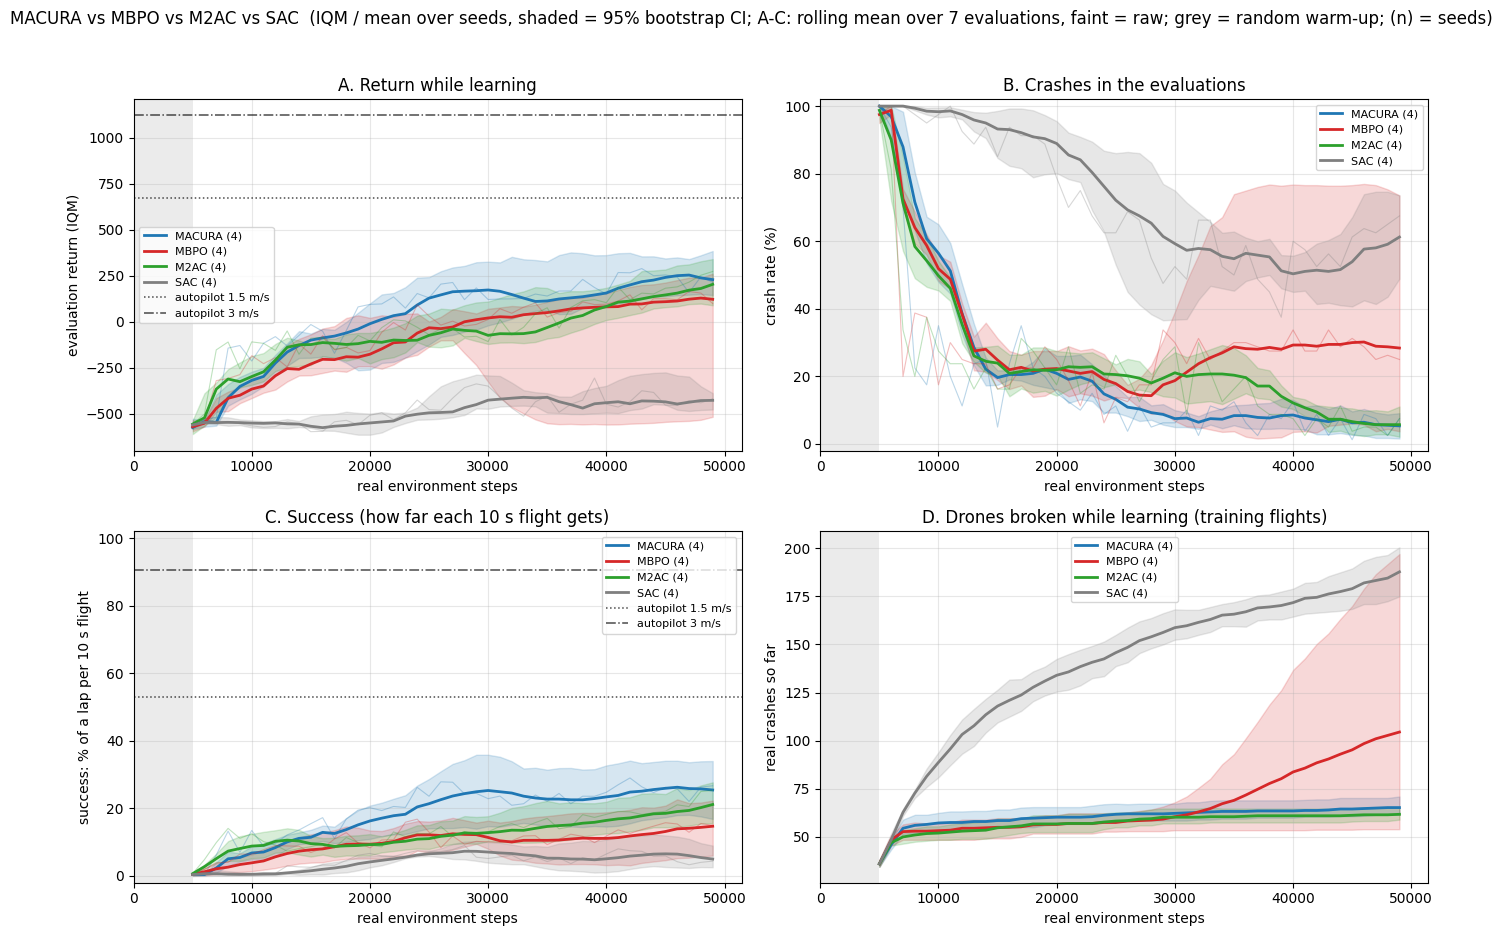

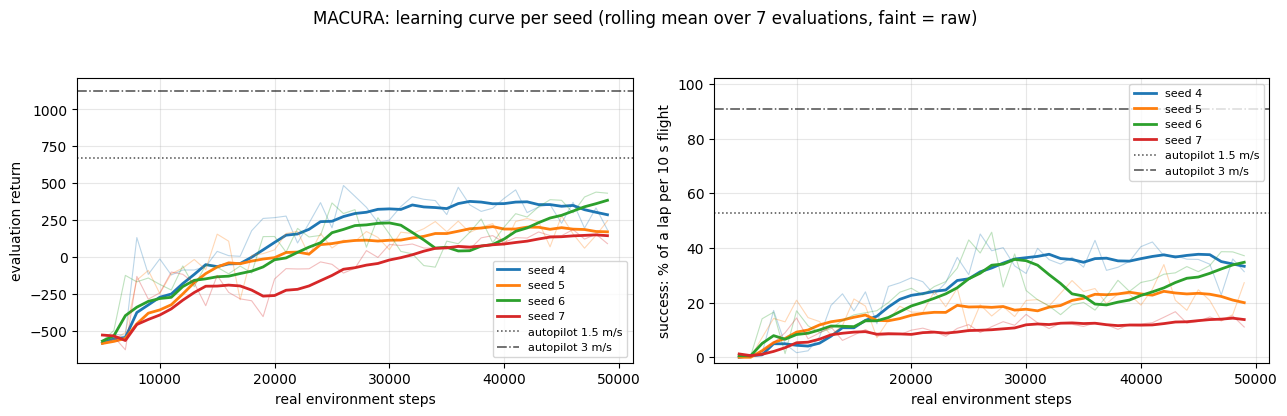

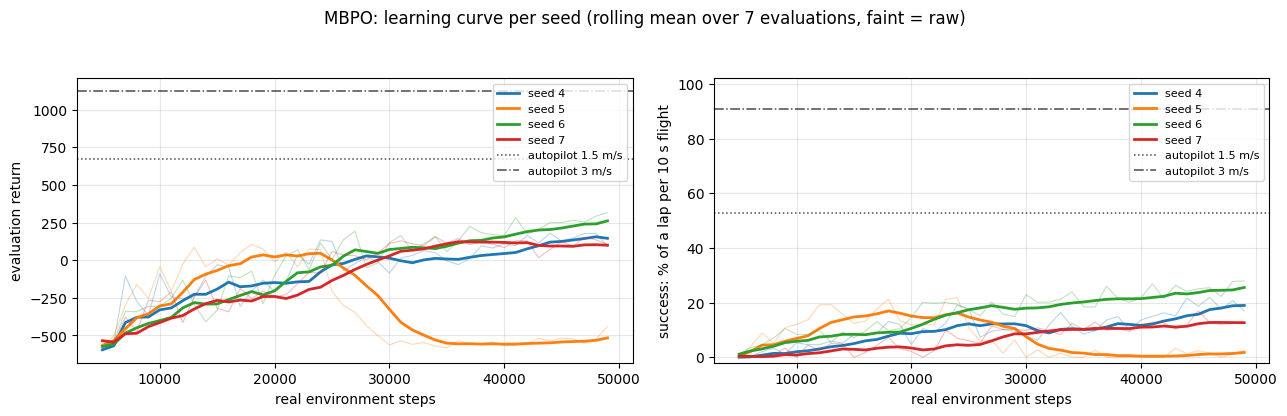

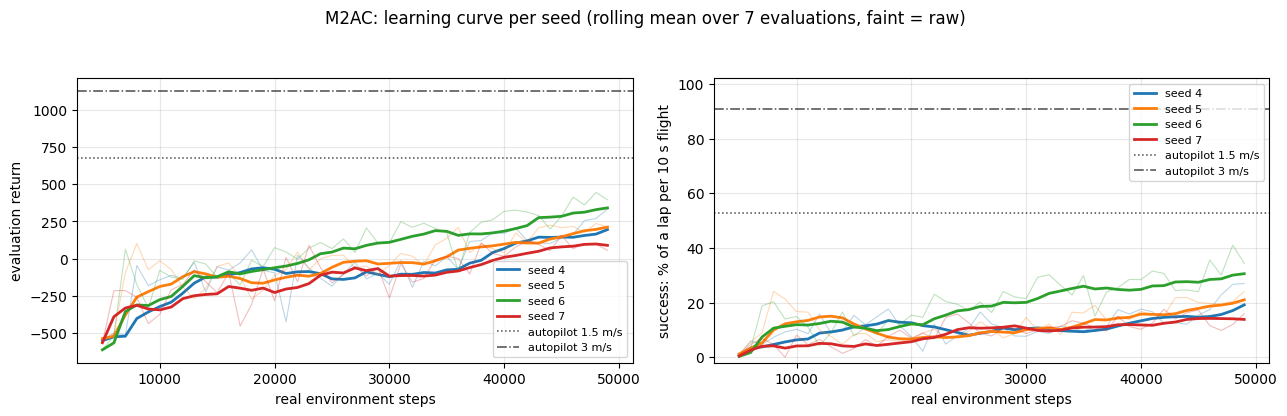

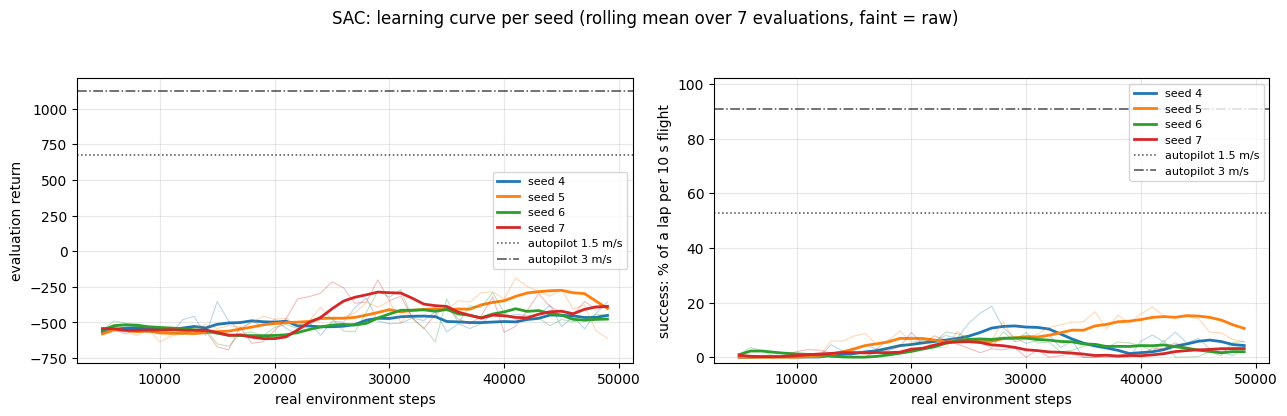

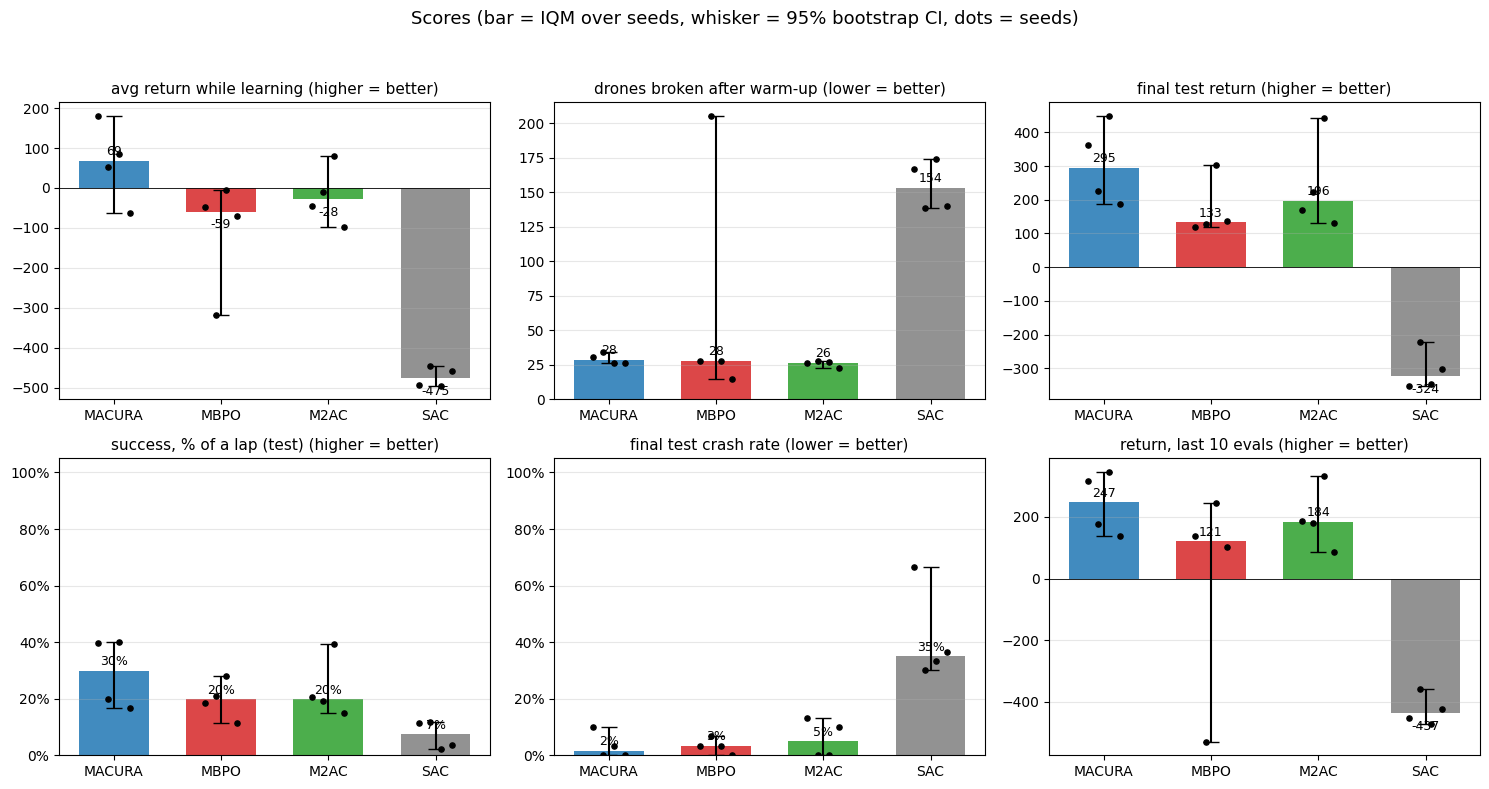

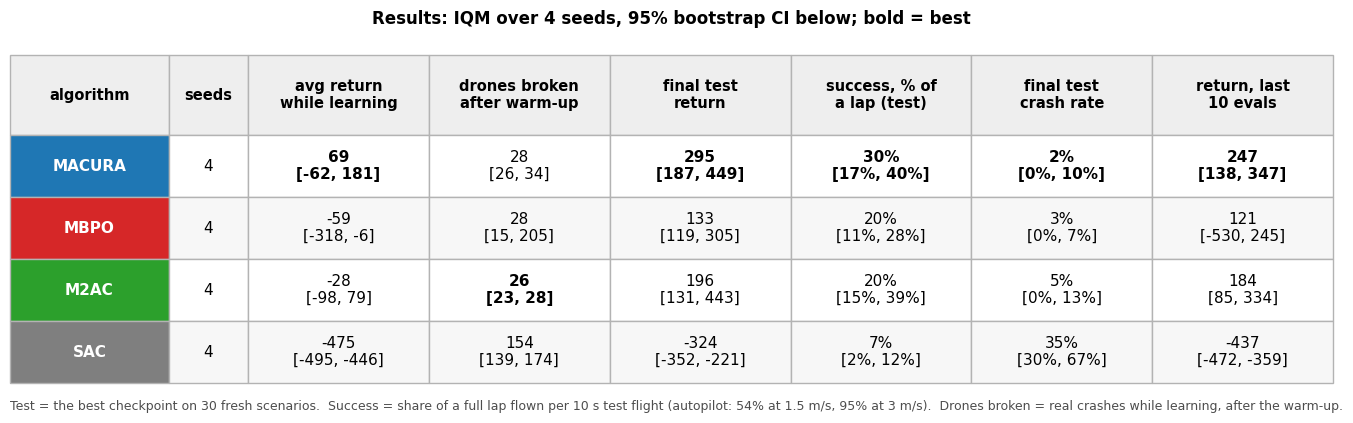

In [5]:
REFS = R.autopilot_reference(cfg.ENV, cache=f"{OUT}/autopilot_reference.json")
F.plot_learning_curves(RUNS, REFS, f"{OUT}/plots/learning_curves_smooth.png", window=7); plt.show()
for algo, runs in R.by_algo(RUNS).items():
    F.plot_algo(runs, REFS, f"{OUT}/plots/{algo}_per_seed.png", window=7); plt.show()
F.plot_scores(RUNS, f"{OUT}/plots/scores.png"); plt.show()
F.plot_summary_table(RUNS, f"{OUT}/plots/summary_table.png"); plt.show()

MACURA trusted 69% of a full 10-step imagination (average trip 6.9/10); steps passing its trust check: fast descents 67%, normal flight 94%
MBPO trusted 100% of what it imagined (no trust check); 13% of it was above MACURA's threshold
M2AC kept the 25% least uncertain imagined steps; 2% of those were above MACURA's threshold


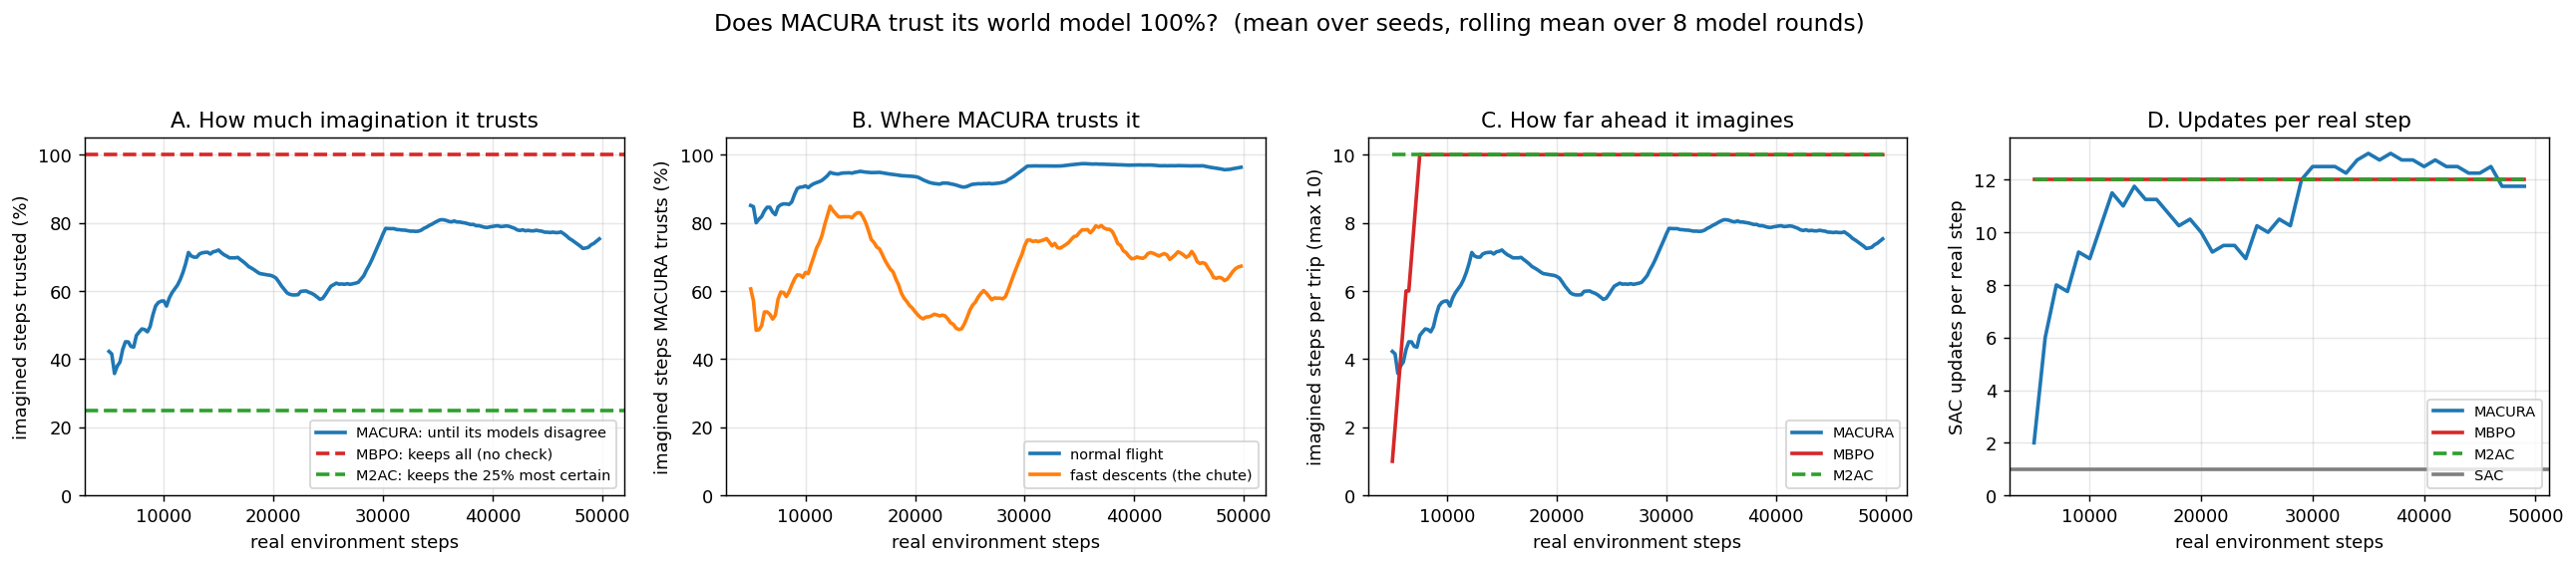

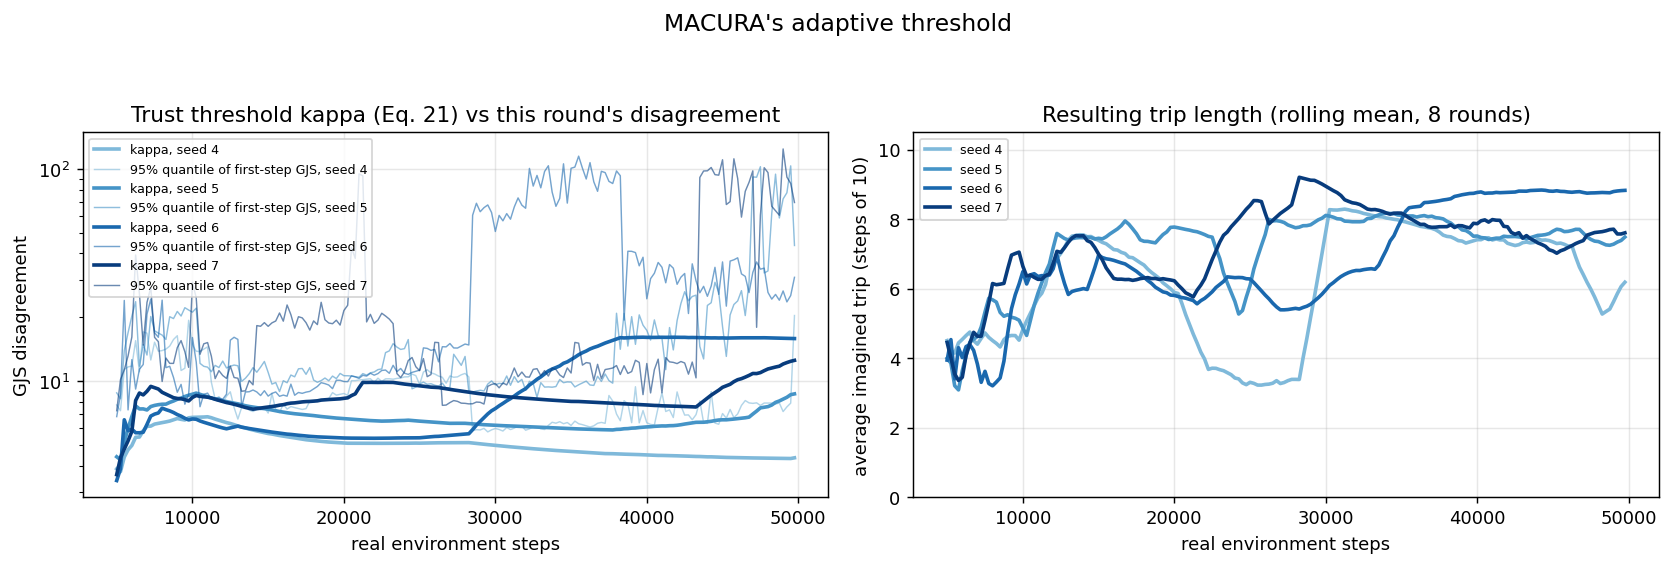

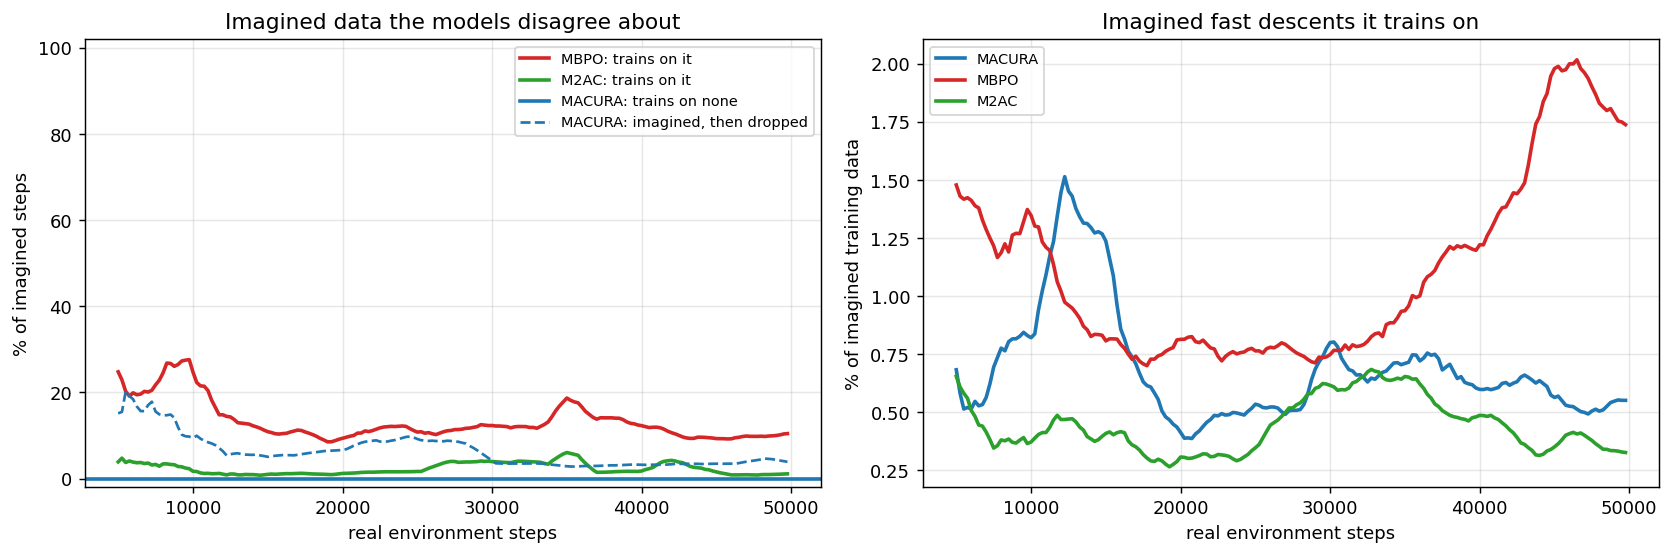

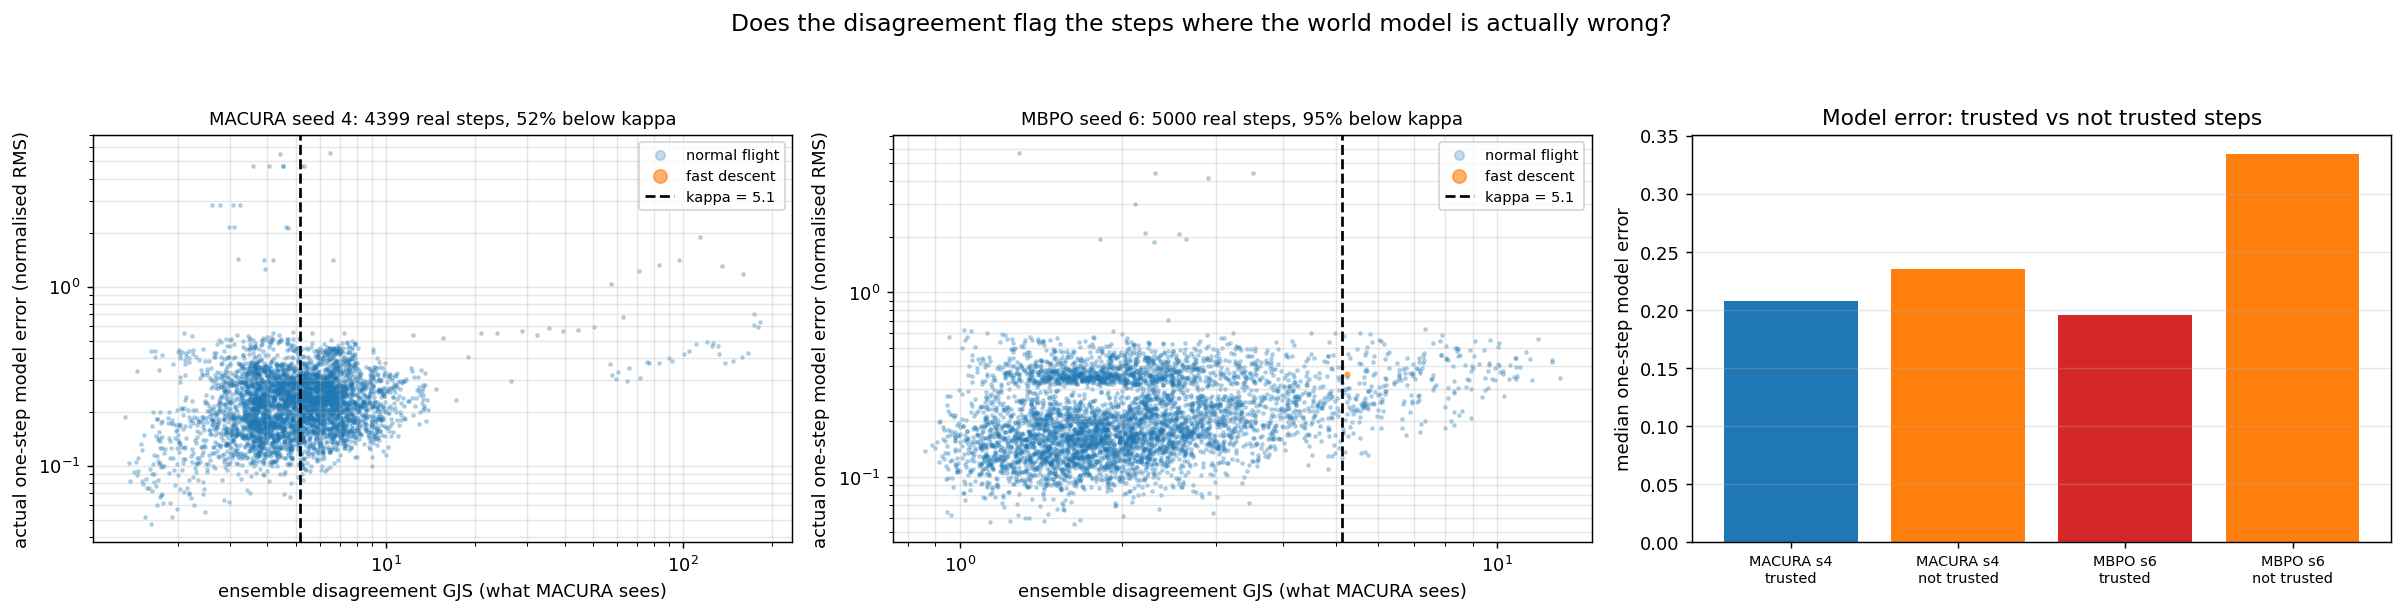

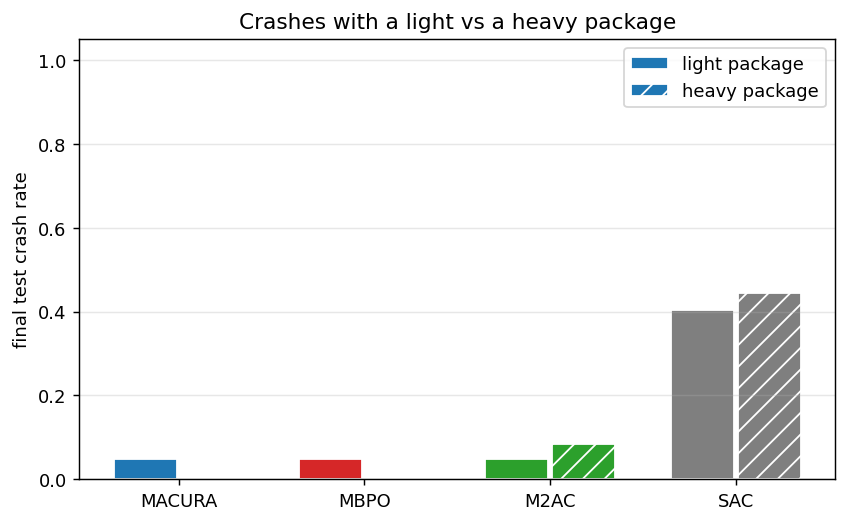

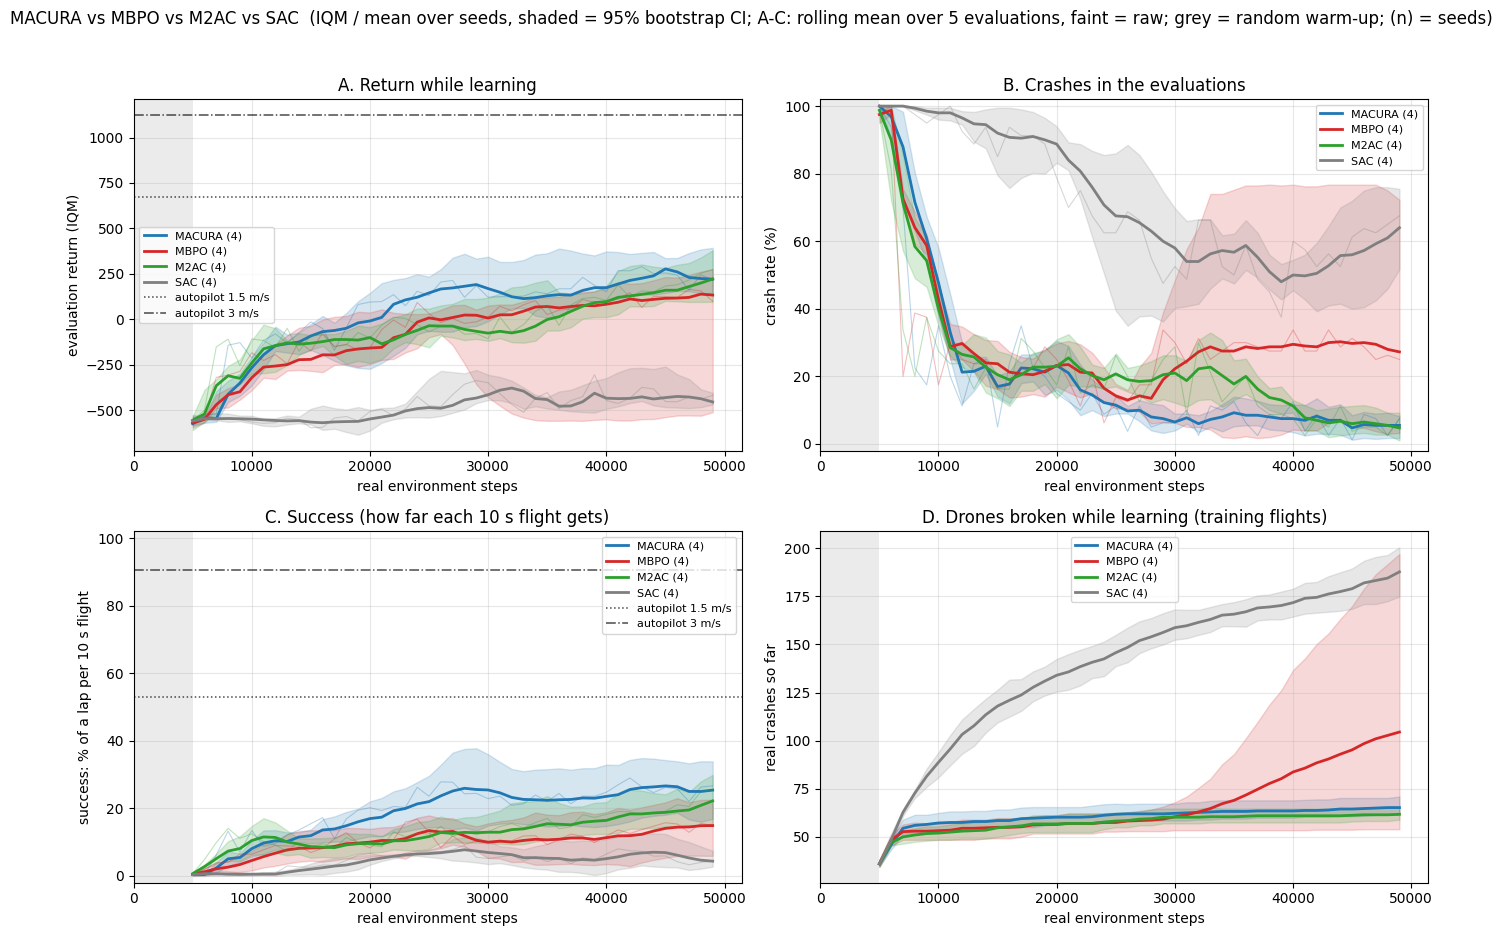

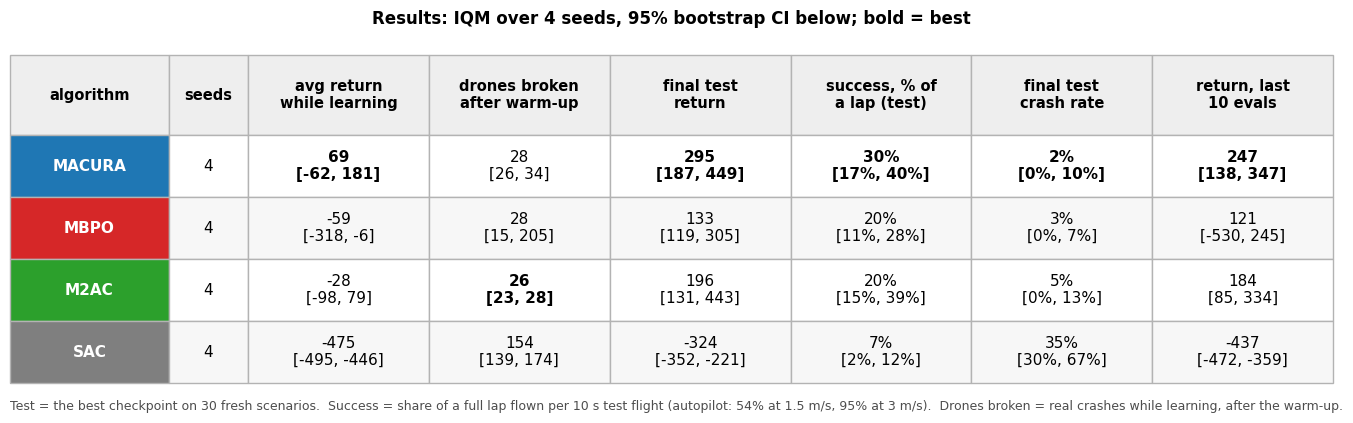

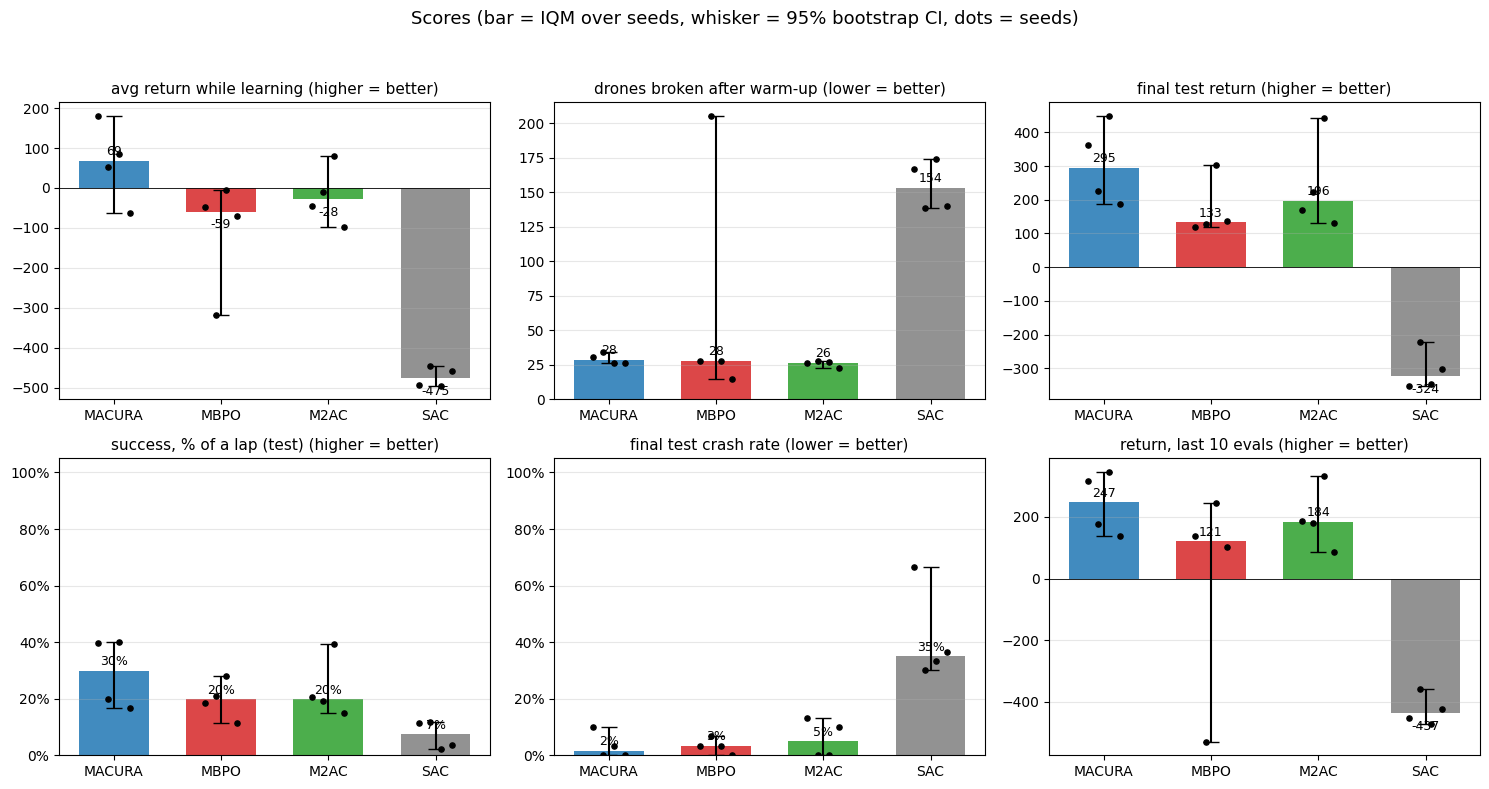

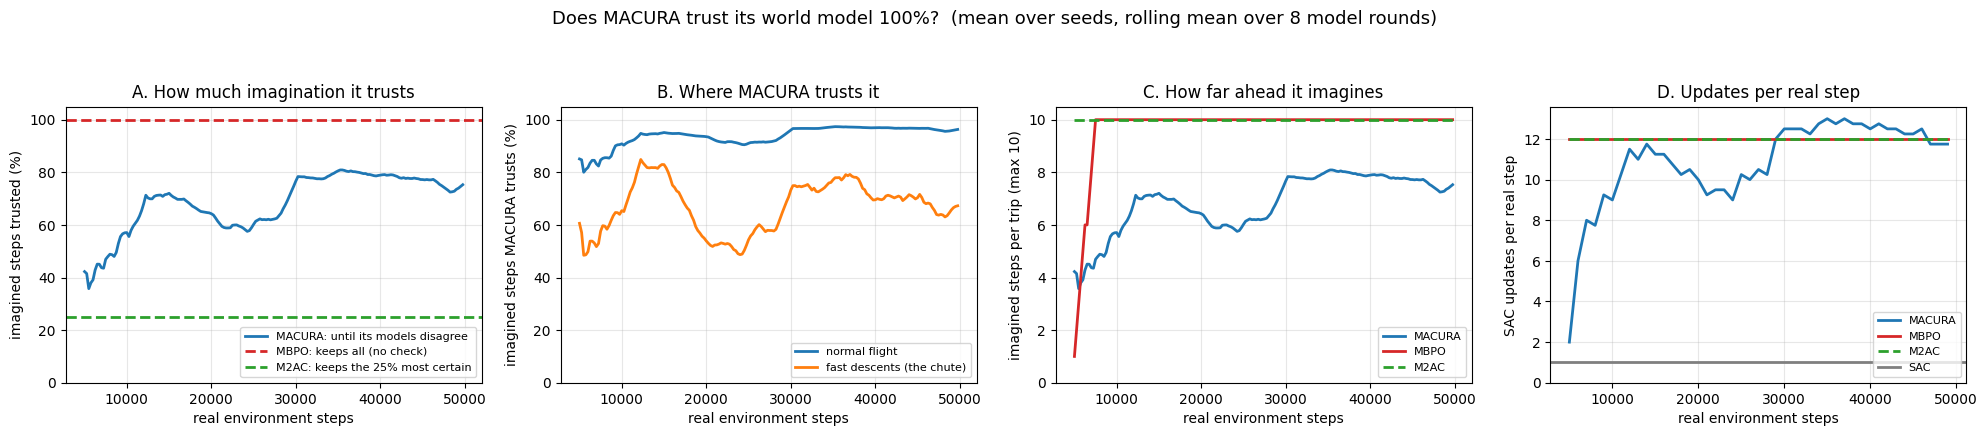

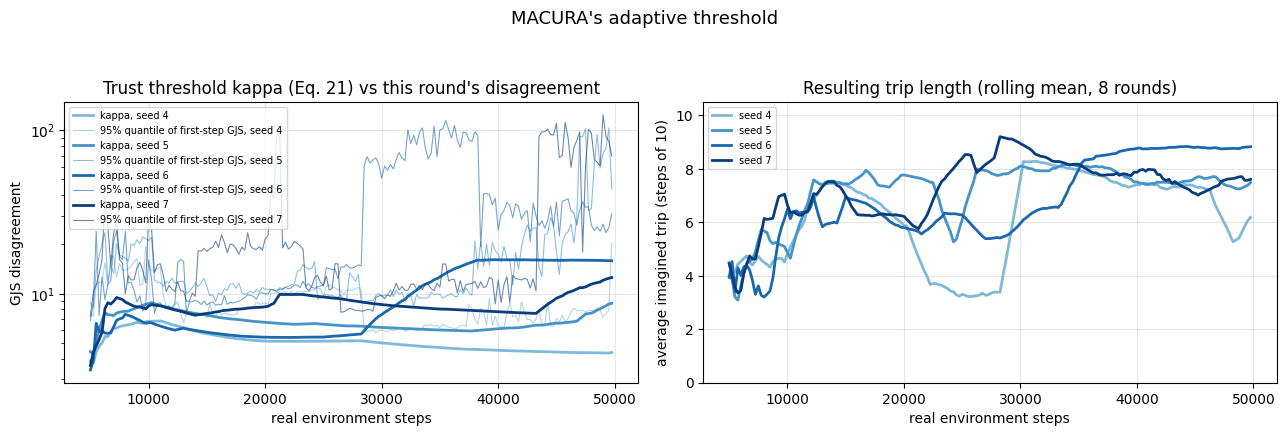

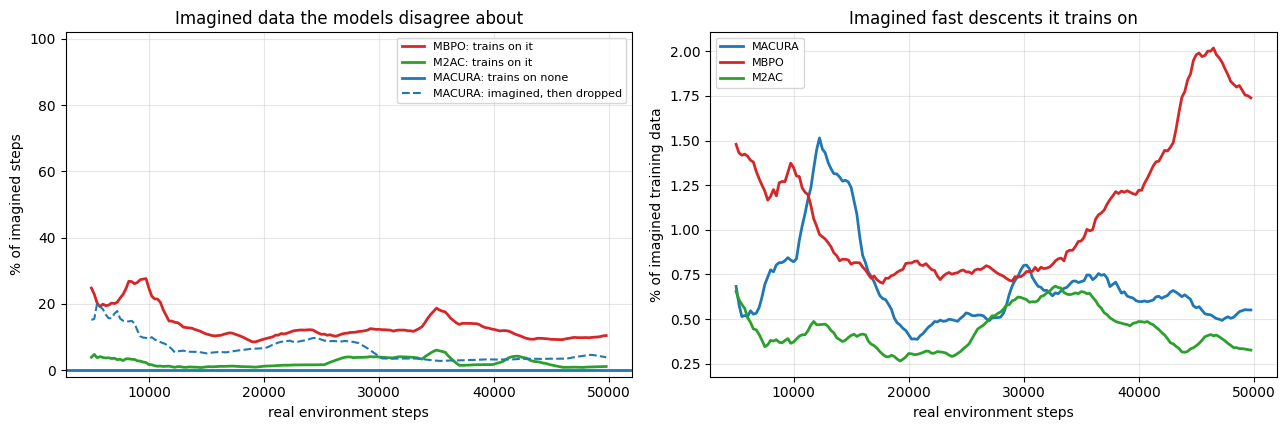

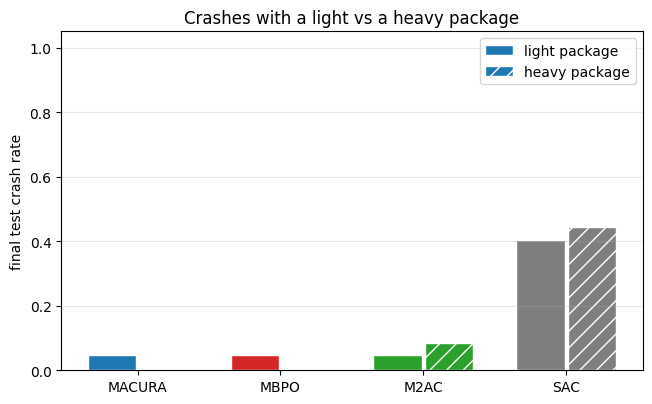

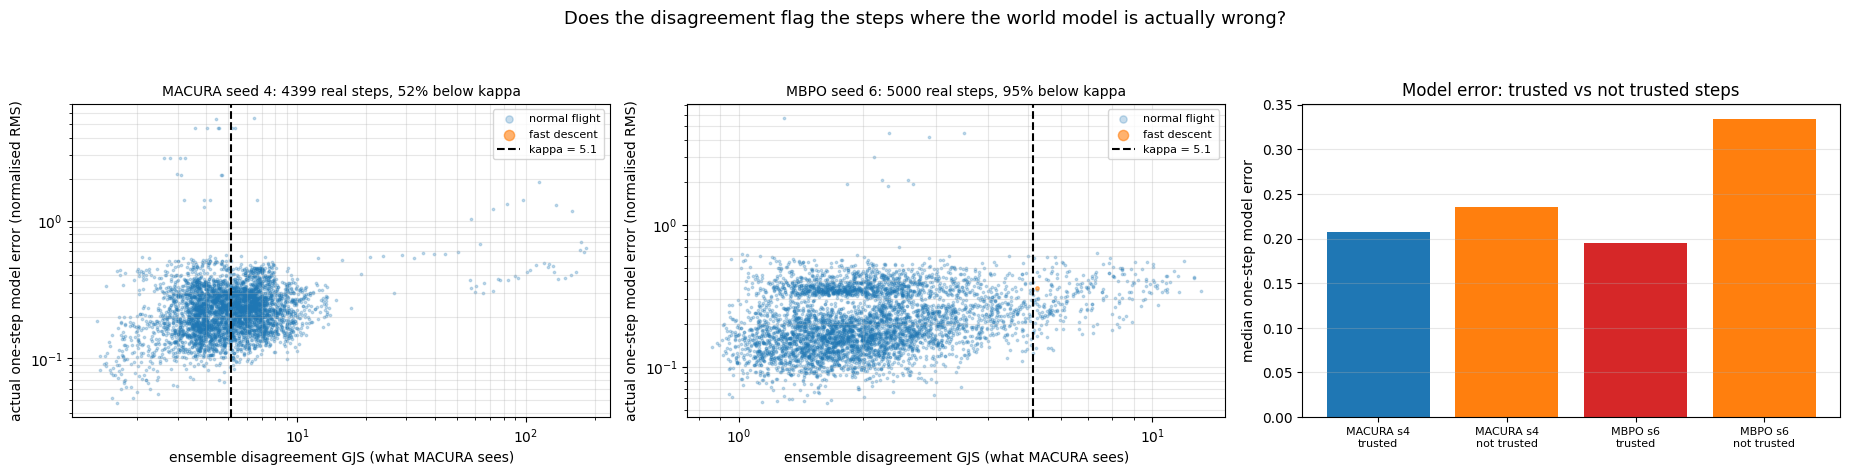

In [6]:
print(R.trust_summary(RUNS))
made = report.build(RUNS, cfg.CFG, OUT, check=True)
for name in ["model_trust", "kappa", "untrusted_data", "model_check", "crash_by_payload"]:
    if name in made:
        display(Image(made[name]))

## 3. Test on 50 new scenarios
Every seed's best checkpoint flies the same 50 new scenarios (seeds 3000-3049).

In [7]:
TESTS = T.test_all(RUNS, cfg.CFG, episodes=EPISODES)
tables = T.test_tables(TESTS)
display(Markdown(tables["summary"]))
display(Markdown(tables["per_seed"]))
for table in tables["paired"]:
    display(Markdown(table))
R.autopilot_reference(cfg.ENV, seed_base=T.TEST_SEED_BASE, episodes=EPISODES, cache=f"{OUT}/autopilot_new_test.json")

| | seeds | test return | lap progress per flight | crash rate | time losing lift | fastest descent (m/s) |
|---|---|---|---|---|---|---|
| MACURA | 4 | 333 [173, 422] | 31% [18%, 42%] | 4% [0%, 6%] | 0.3% [0.0%, 3.4%] | 0.79 [0.49, 1.25] |
| MBPO | 4 | 158 [99, 355] | 22% [14%, 30%] | 2% [0%, 14%] | 0.2% [0.0%, 1.4%] | 0.75 [0.37, 0.86] |
| M2AC | 4 | 267 [117, 383] | 24% [15%, 41%] | 6% [0%, 10%] | 0.9% [0.3%, 2.5%] | 0.89 [0.53, 1.37] |
| SAC | 4 | -312 [-385, -242] | 7% [4%, 10%] | 35% [28%, 68%] | 0.4% [0.3%, 0.7%] | 1.10 [1.01, 1.20] |

IQM over seeds [95% bootstrap CI]; each seed = its best checkpoint on the same 50 new scenarios (seeds 3000-3049).

| algorithm | seed | test return | lap progress per flight | crash rate | time losing lift | fastest descent (m/s) |
|---|---|---|---|---|---|---|
| MACURA | 4 | 422 | 42% | 4% | 0.4% | 0.94 |
| MACURA | 5 | 250 | 24% | 0% | 0.1% | 0.49 |
| MACURA | 6 | 417 | 38% | 6% | 3.4% | 1.25 |
| MACURA | 7 | 173 | 18% | 4% | 0.0% | 0.65 |
| MBPO | 4 | 183 | 21% | 2% | 1.4% | 0.81 |
| MBPO | 5 | 99 | 24% | 14% | 0.0% | 0.70 |
| MBPO | 6 | 355 | 30% | 0% | 0.4% | 0.37 |
| MBPO | 7 | 133 | 14% | 2% | 0.1% | 0.86 |
| M2AC | 4 | 280 | 26% | 6% | 0.4% | 1.05 |
| M2AC | 5 | 253 | 22% | 0% | 0.3% | 0.72 |
| M2AC | 6 | 383 | 41% | 6% | 1.5% | 1.37 |
| M2AC | 7 | 117 | 15% | 10% | 2.5% | 0.53 |
| SAC | 4 | -385 | 8% | 68% | 0.3% | 1.03 |
| SAC | 5 | -242 | 10% | 28% | 0.5% | 1.18 |
| SAC | 6 | -314 | 4% | 30% | 0.4% | 1.01 |
| SAC | 7 | -310 | 5% | 40% | 0.7% | 1.20 |

#### Test: MACURA vs MBPO

| MACURA - MBPO | seed 4 | seed 5 | seed 6 | seed 7 | mean | MACURA better in |
|---|---|---|---|---|---|---|
| test return | +238 | +151 | +62 | +40 | +123 | 4 of 4 |
| lap progress per flight | +21% | +0% | +8% | +4% | +8% | 4 of 4 |
| crash rate | +2% | -14% | +6% | +2% | -1% | 1 of 4 |
| time losing lift | -1.1% | +0.1% | +3.0% | -0.1% | +0.5% | 2 of 4 |

#### Test: MACURA vs M2AC

| MACURA - M2AC | seed 4 | seed 5 | seed 6 | seed 7 | mean | MACURA better in |
|---|---|---|---|---|---|---|
| test return | +142 | -4 | +34 | +56 | +57 | 3 of 4 |
| lap progress per flight | +16% | +2% | -3% | +3% | +4% | 3 of 4 |
| crash rate | -2% | +0% | +0% | -6% | -2% | 2 of 4 |
| time losing lift | -0.0% | -0.2% | +2.0% | -2.5% | -0.2% | 3 of 4 |

#### Test: MACURA vs SAC

| MACURA - SAC | seed 4 | seed 5 | seed 6 | seed 7 | mean | MACURA better in |
|---|---|---|---|---|---|---|
| test return | +807 | +492 | +731 | +483 | +628 | 4 of 4 |
| lap progress per flight | +34% | +14% | +34% | +13% | +24% | 4 of 4 |
| crash rate | -64% | -28% | -24% | -36% | -38% | 4 of 4 |
| time losing lift | +0.1% | -0.3% | +3.0% | -0.7% | +0.5% | 2 of 4 |

{'autopilot 1.5 m/s': {'return': 679.4393128652127,
  'laps': 0.536960985626281,
  'crash': 0.0},
 'autopilot 3 m/s': {'return': 1145.84911544141,
  'laps': 0.9211498973305916,
  'crash': 0.02}}

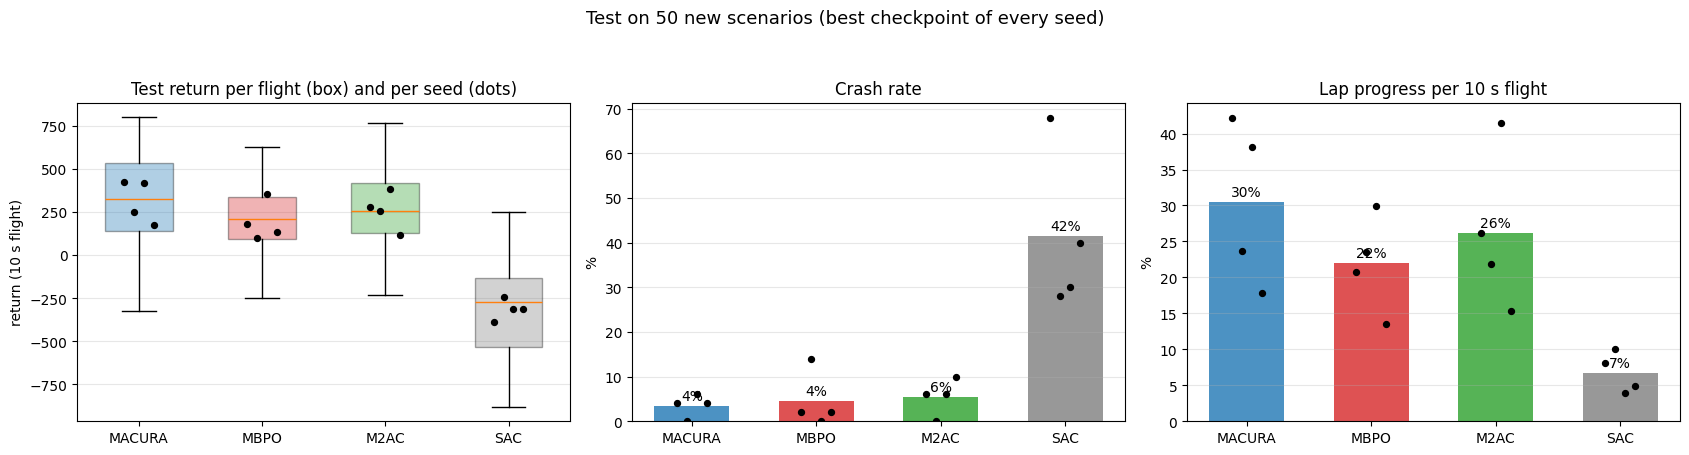

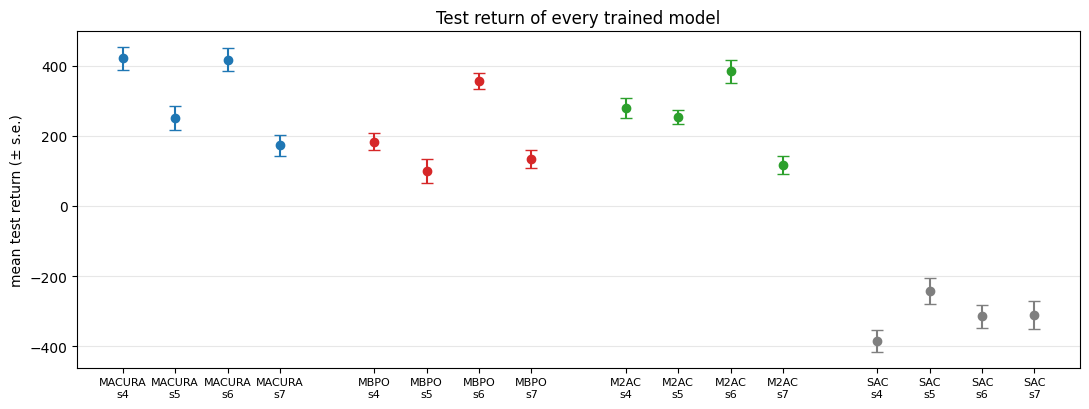

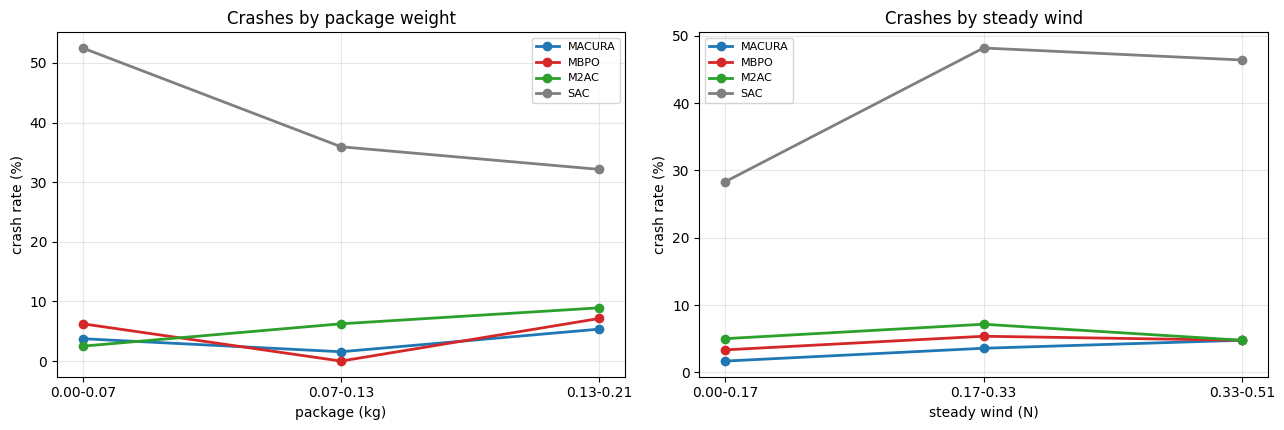

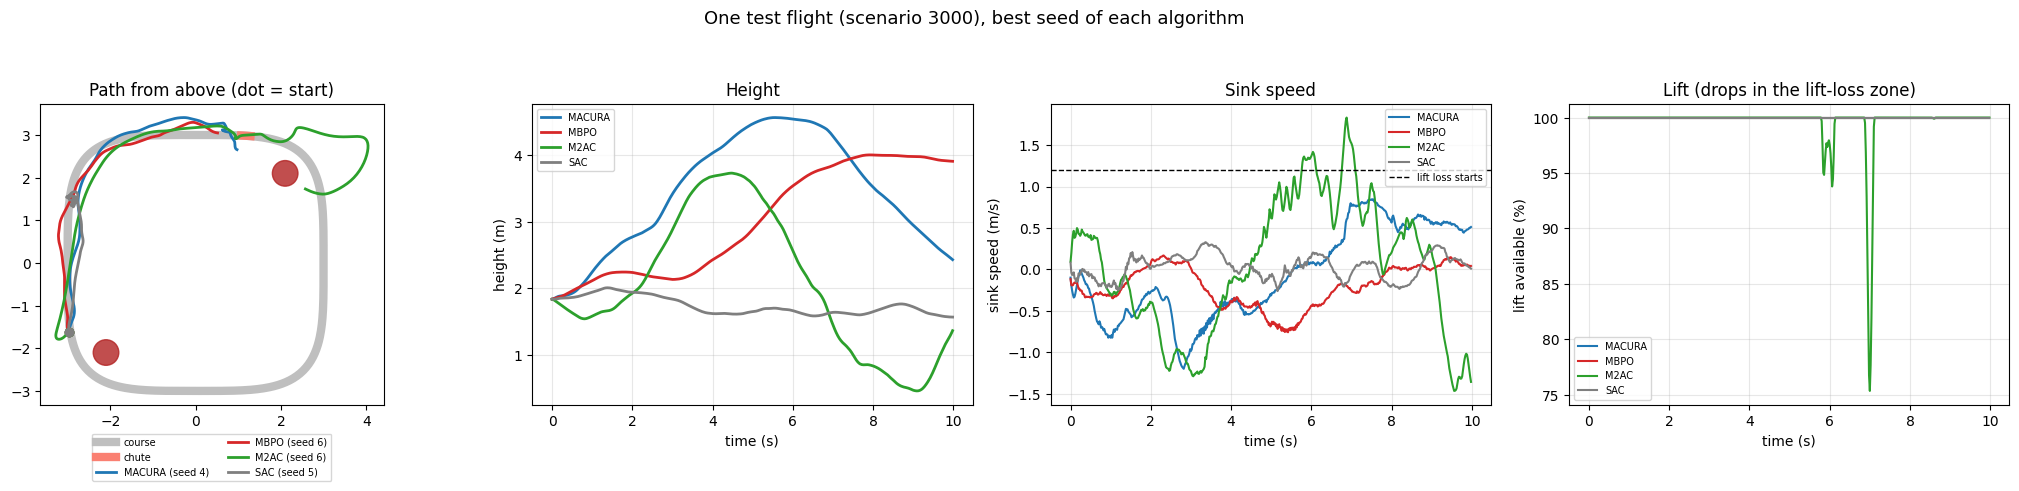

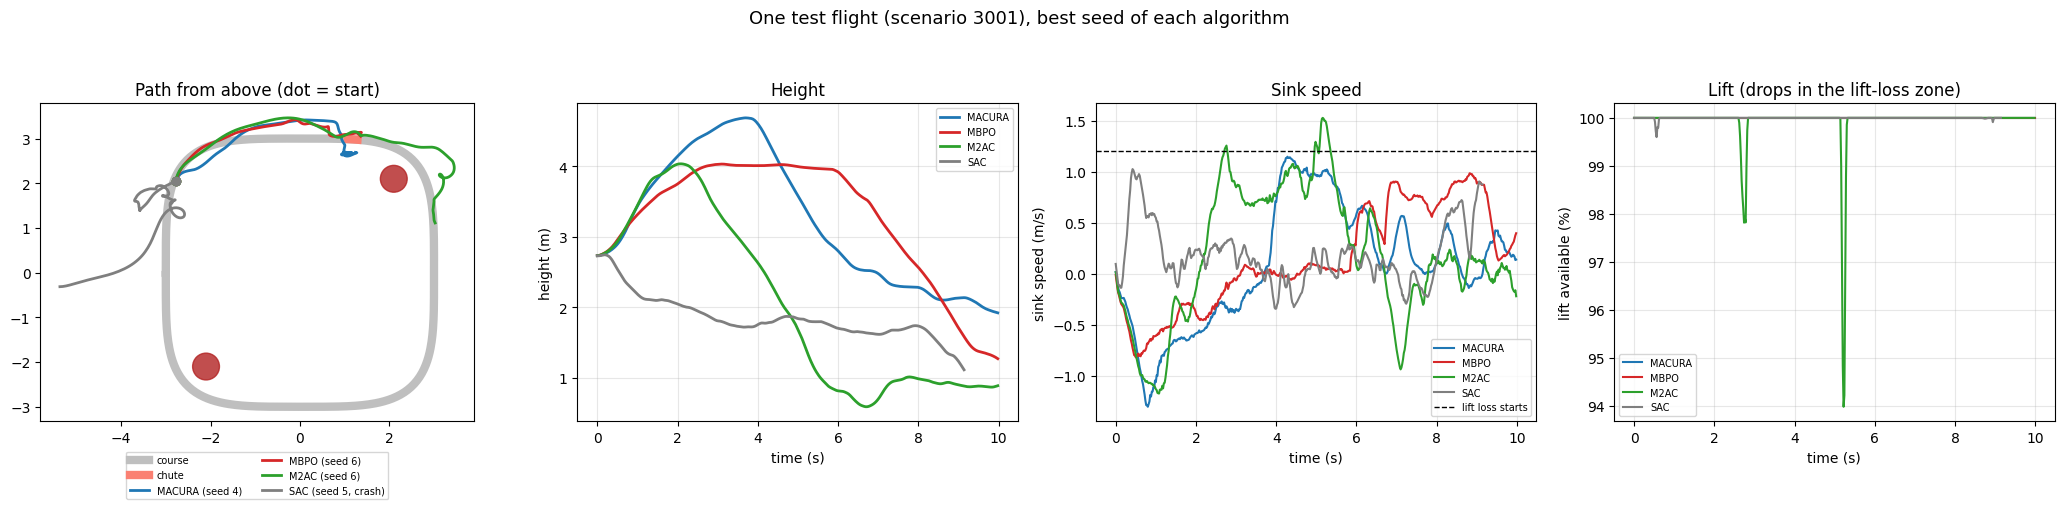

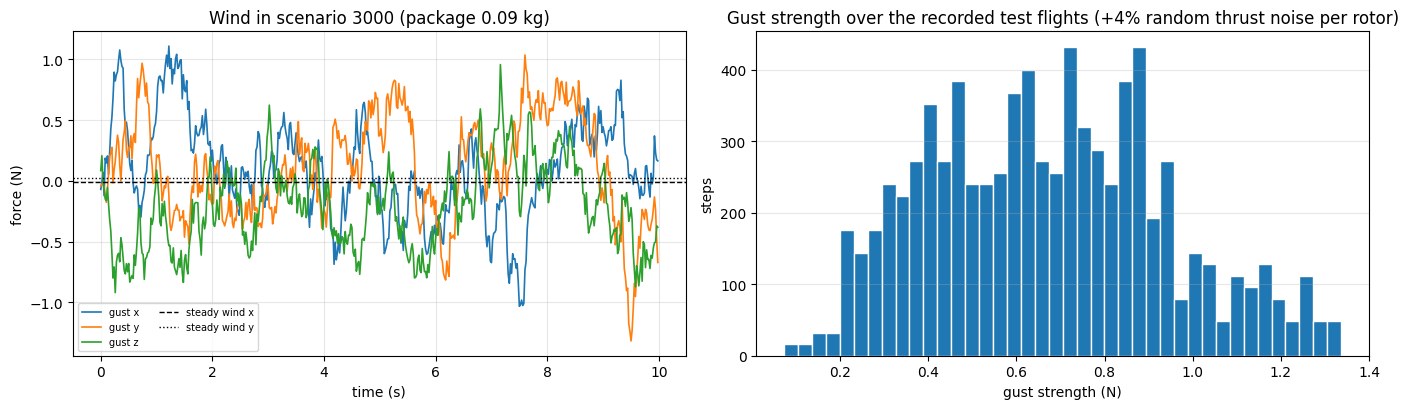

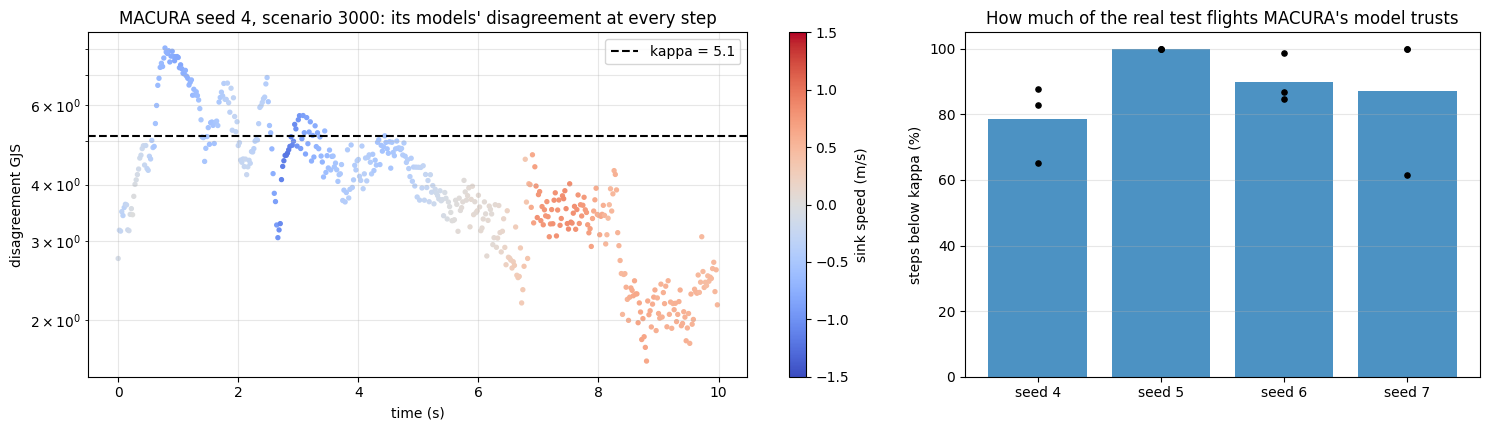

In [8]:
TF.plot_test_scores(TESTS, f"{OUT}/plots/test_scores.png"); plt.show()
TF.plot_test_seeds(TESTS, f"{OUT}/plots/test_seeds.png"); plt.show()
TF.plot_test_conditions(TESTS, f"{OUT}/plots/test_conditions.png"); plt.show()
TF.plot_test_flights(TESTS, cfg.CFG, trace=0, save_path=f"{OUT}/plots/test_flight_0.png"); plt.show()
TF.plot_test_flights(TESTS, cfg.CFG, trace=1, save_path=f"{OUT}/plots/test_flight_1.png"); plt.show()
TF.plot_test_noise(TESTS, save_path=f"{OUT}/plots/test_wind.png"); plt.show()
TF.plot_test_trust(TESTS, f"{OUT}/plots/test_trust.png"); plt.show()

## 4. Test videos
All four best models, each algorithm's seeds, and MACURA vs MBPO for 30 s.

In [9]:
def trust_of(run):
    return {"ensemble": R.ensemble_checkpoint(run), "kappa": R.kappa_at(run)}

def show(path):
    if path:
        display(Video(path, embed=True, width=960))

if VIDEOS:
    best = {R.NAMES[a]: R.best_run(runs) for a, runs in R.by_algo(RUNS).items()}
    trust = {name: trust_of(r) for name, r in best.items() if r["algo"] == "macura"}
    pilots = {name: R.checkpoint(r) for name, r in best.items()}
    scenarios = (T.TEST_SEED_BASE, T.TEST_SEED_BASE + 1, T.TEST_SEED_BASE + 2)
    show(V.record_race(cfg.CFG, pilots, f"{OUT}/videos/test_all.mp4", seeds=scenarios, trust=trust, frame_step=3, fps=17))

    for algo, runs in R.by_algo(RUNS).items():
        pilots = {f"{R.NAMES[algo]} seed {r['seed']}": R.checkpoint(r) for r in runs}
        seed_trust = {f"{R.NAMES[algo]} seed {r['seed']}": trust_of(r) for r in runs if algo == "macura"}
        show(V.record_race(cfg.CFG, pilots, f"{OUT}/videos/test_{algo}_seeds.mp4", seeds=(T.TEST_SEED_BASE + 3,),
                           trust=seed_trust, frame_step=3, fps=17))

    duo = {name: R.checkpoint(r) for name, r in best.items() if name in ("MACURA", "MBPO")}
    show(V.record_race(cfg.CFG, duo, f"{OUT}/videos/test_30s.mp4", seeds=(T.TEST_SEED_BASE + 4,), trust=trust,
                       frame_step=3, fps=17, max_steps=1500))

  MACURA: 0.8 laps in 3 flights, crashed 0, model trusted 79% of the steps
  MBPO: 0.9 laps in 3 flights, crashed 0
  M2AC: 1.3 laps in 3 flights, crashed 0
  SAC: 0.2 laps in 3 flights, crashed 1


  MACURA seed 4: 0.6 laps in 1 flights, crashed 0, model trusted 27% of the steps
  MACURA seed 5: 0.6 laps in 1 flights, crashed 0, model trusted 100% of the steps
  MACURA seed 6: 0.3 laps in 1 flights, crashed 0, model trusted 100% of the steps
  MACURA seed 7: 0.2 laps in 1 flights, crashed 0, model trusted 100% of the steps


  MBPO seed 4: 0.2 laps in 1 flights, crashed 0
  MBPO seed 5: 0.6 laps in 1 flights, crashed 0
  MBPO seed 6: 0.4 laps in 1 flights, crashed 0
  MBPO seed 7: -0.0 laps in 1 flights, crashed 0


  M2AC seed 4: 0.2 laps in 1 flights, crashed 0
  M2AC seed 5: 0.3 laps in 1 flights, crashed 0
  M2AC seed 6: 0.5 laps in 1 flights, crashed 0
  M2AC seed 7: -0.1 laps in 1 flights, crashed 0


  SAC seed 4: 0.1 laps in 1 flights, crashed 1
  SAC seed 5: 0.1 laps in 1 flights, crashed 0
  SAC seed 6: -0.0 laps in 1 flights, crashed 0
  SAC seed 7: -0.0 laps in 1 flights, crashed 1


  MACURA: 1.4 laps in 1 flights, crashed 0, model trusted 62% of the steps
  MBPO: 0.6 laps in 1 flights, crashed 0


## 5. Final comparison

| algorithm | avg return while learning | drones broken | test return | test lap progress | test crash rate |
|---|---|---|---|---|---|
| MACURA | 69 | 28 | 333 | 31% | 4% |
| MBPO | -59 | 28 | 158 | 22% | 2% |
| M2AC | -28 | 26 | 267 | 24% | 6% |
| SAC | -475 | 154 | -312 | 7% | 35% |

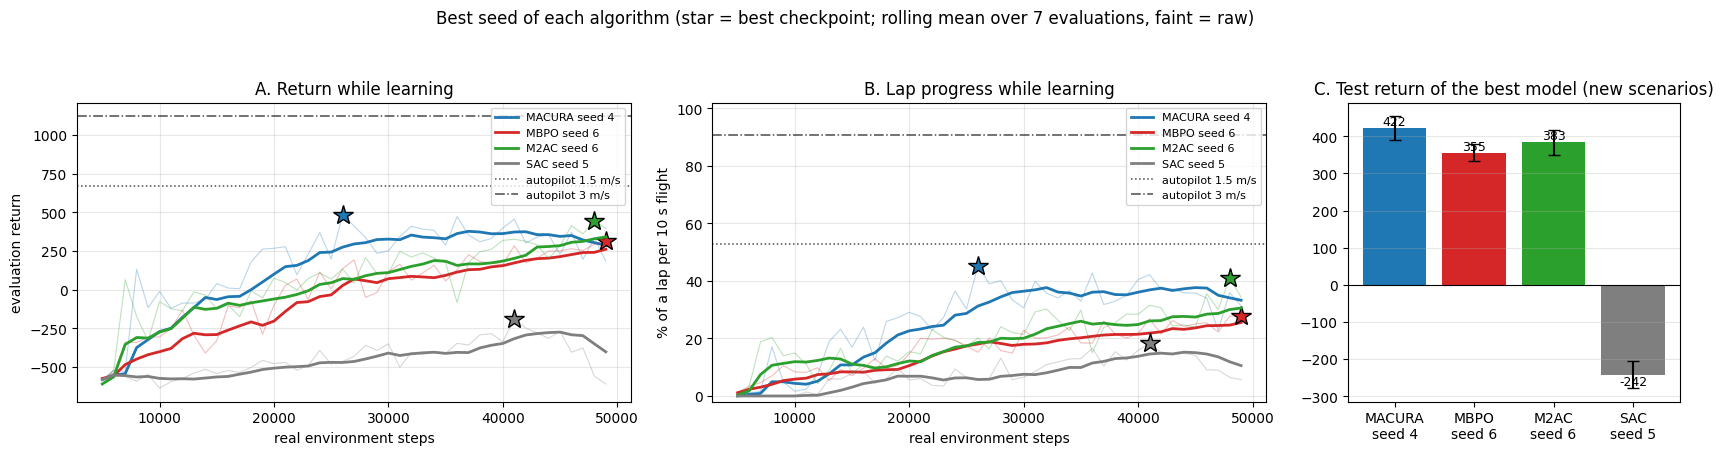

In [10]:
TABLE = T.final_table(RUNS, TESTS)
display(Markdown(TABLE))
F.plot_best(RUNS, REFS, f"{OUT}/plots/best_results.png", tests=TESTS, window=7); plt.show()

summary = [TABLE, R.summary_markdown(RUNS), R.per_seed_markdown(RUNS), tables["summary"], tables["per_seed"],
           *tables["paired"], R.where_table(RUNS)]
open(f"{OUT}/summary.md", "w").write("\n\n".join(summary))
json.dump([{"algo": r["algo"], "seed": r["seed"], "episodes": r["episodes"]} for r in TESTS],
          open(f"{OUT}/test_results.json", "w"), default=float)

## 6. Simulator

In [11]:
from src.envs import drone_env
from src.algorithms.sac import load_agent

env, obs_dim, act_dim = drone_env.make_env(cfg.ENV)
for r in RUNS:
    load_agent(R.checkpoint(r), obs_dim, act_dim, cfg.SAC)
print(f"all {len(RUNS)} models load. In a terminal:")
print("  mjpython simulate.py")
print("  mjpython simulate.py --scenarios 3000 3001 3002")
print("  mjpython simulate.py --algos macura mbpo --seconds 30 --follow MACURA")

all 16 models load. In a terminal:
  mjpython simulate.py
  mjpython simulate.py --scenarios 3000 3001 3002
  mjpython simulate.py --algos macura mbpo --seconds 30 --follow MACURA


## 7. Recap

In [12]:
display(Markdown(f"**{len(RUNS)} trained models** ({len(R.by_algo(RUNS))} algorithms), each tested on {EPISODES} new scenarios"))
display(Markdown(TABLE))
display(Markdown(T.wins(TESTS)))
print("plots: ", ", ".join(sorted(os.listdir(f"{OUT}/plots"))))
print("videos:", ", ".join(sorted(os.listdir(f"{OUT}/videos"))))
print("summary:", f"{OUT}/summary.md")

**16 trained models** (4 algorithms), each tested on 50 new scenarios

| algorithm | avg return while learning | drones broken | test return | test lap progress | test crash rate |
|---|---|---|---|---|---|
| MACURA | 69 | 28 | 333 | 31% | 4% |
| MBPO | -59 | 28 | 158 | 22% | 2% |
| M2AC | -28 | 26 | 267 | 24% | 6% |
| SAC | -475 | 154 | -312 | 7% | 35% |

- MACURA vs MBPO: better in 4 of 4 seeds, test return +123 on average
- MACURA vs M2AC: better in 3 of 4 seeds, test return +57 on average
- MACURA vs SAC: better in 4 of 4 seeds, test return +628 on average

plots:  best_results.png, crash_by_payload.png, kappa.png, learning_curves.png, learning_curves_smooth.png, m2ac_per_seed.png, macura_per_seed.png, mbpo_per_seed.png, model_check.png, model_trust.png, sac_per_seed.png, scores.png, summary_table.png, test_conditions.png, test_flight_0.png, test_flight_1.png, test_scores.png, test_seeds.png, test_trust.png, test_wind.png, untrusted_data.png
videos: test_30s.mp4, test_all.mp4, test_m2ac_seeds.mp4, test_macura_seeds.mp4, test_mbpo_seeds.mp4, test_sac_seeds.mp4
summary: results/summary.md
